# Binary Image Classification for Pedestrian Detection via Spiking Neural Networks (SNNs)

This notebook implements an end-to-end Neuromorphic Machine Learning Operations (NMLOps) pipeline for a **Pedestrian Image Classification** task. Given an entire frame or image as input, the objective is to perform binary classification to determine the presence of at least one pedestrian using a Spiking Neural Network (SNN), without performing spatial localization.

## 1. Functional System Setup & Dependencies

Initializes the computational environment by loading fundamental science and deep learning libraries, handling automated fallback installation for neuromorphic tools, and configuring the execution hardware alongside mathematical determinism.

### 1.1 Dynamic Dependency Management

Handles core environment imports (PyTorch, SciKit-Learn, visualization tools) and features an automated fallback mechanism to dynamically install and import `snntorch` (with surrogates) and `nni` (`TpeTuner`) if missing (e.g., when executing for the first time in a cloud-hosted environment like Google Colab).

In [1]:
import os
import sys
import subprocess
import xml.etree.ElementTree as ET
from PIL import Image
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sn
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import copy
import gc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

try:
    import snntorch as snn
    from snntorch import surrogate
    from nni.algorithms.hpo.tpe_tuner import TpeTuner
except ModuleNotFoundError:
    print("Required packages (snntorch/nni) not found. Environment setup initiated.")
    print("Installing snntorch, nni and required dependencies...")
    
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "snntorch", "nni"])
    print("Installation complete. Retrying imports...")
    
    import snntorch as snn
    from snntorch import surrogate
    from nni.algorithms.hpo.tpe_tuner import TpeTuner

### 1.2 Global Reproducibility & Mathematical Determinism

Enforces global deterministic seeds across Python, NumPy, PyTorch, and CuDNN. It also restricts CUDA/CuBLAS workspace execution behaviors to guarantee absolute mathematical reproducibility across identical execution environments.

In [2]:
use_seed = True

if use_seed:
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Multi-GPU setup compatibility
    
    # Force PyTorch to use deterministic algorithms
    torch.use_deterministic_algorithms(True)
    
    # Configure CuDNN to maintain strict mathematical consistency
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Reproducibility enabled: global seed set to {seed}.")
else:
    seed = None
    print("Reproducibility disabled: training dynamics might vary across runs.")

Reproducibility enabled: global seed set to 42.


### 1.3 Hardware Acceleration Setup

Detects and assigns the primary execution target (CUDA-enabled GPU or CPU) for tensor operations and network simulations.

In [3]:
if torch.cuda.is_available():
    device = "cuda:0"
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ":4096:8"
else:
    device = "cpu"

## 2. Data Repository Deployment & Environment Diagnostics

Initializes the workspace storage layer by identifying the active infrastructure, managing the localized or remote retrieval of the dataset, and performing an atomic diagnostic check on target path directories.

### 2.1 Runtime Environment Detection

Identifies the active runtime host (Google Colab vs. Local WSL/VS Code) to establish the deterministic root path (ROOTDIR_DATA) for all downstream file systems and operational tasks.

In [4]:
if os.path.exists('/content'):
    # Root directory for Google Colab
    ROOTDIR_DATA = "/content"
    print(f"Environment detected: Google Colab.")
else:
    # Root directory for local environment (WSL / VS Code)
    ROOTDIR_DATA = "."
    print(f"Environment detected: Local (WSL).")

Environment detected: Local (WSL).


### 2.2 Cloud-Targeted Dataset Cloning & Workspace Extraction

Automates dataset deployment exclusively when running in Google Colab. If the target data directory is missing from the ephemeral cloud workspace, it clones the remote GitHub repository into a temporary folder, extracts the core dataset to the final destination directory, and performs a complete cleanup of workspace remnants.

**Note:** For local execution (WSL), this automation is intentionally bypassed, assuming the dataset has already been cloned or structured manually within the local project directory root.

In [5]:
REPO_URL = "https://github.com/tmmssd/pedestrian_detection.git"
CLONE_DIR = os.path.join(ROOTDIR_DATA, "repo_temp")
FINAL_DATA_DIR = os.path.join(ROOTDIR_DATA, "data")

if not os.path.exists(FINAL_DATA_DIR):
    print(f"Data folder not found. Downloading dataset from GitHub repository...")
    
    # Remove any corrupted or partial directory remnants from previous attempts
    subprocess.run(["rm", "-rf", CLONE_DIR])
    subprocess.run(["rm", "-rf", FINAL_DATA_DIR])
        
    print("Cloning repository...")
    result = subprocess.run(["git", "clone", REPO_URL, CLONE_DIR], capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"\n[CRITICAL] Git clone failed with exit code {result.returncode}.")
        print(f"Git Error Message:\n{result.stderr}")
        raise RuntimeError("Could not clone the repository. See the Git error message above.")
    
    src_data_path = os.path.join(CLONE_DIR, "data")
    if os.path.exists(src_data_path):
        subprocess.run(["cp", "-r", src_data_path, FINAL_DATA_DIR], check=True)
        print("Dataset successfully downloaded and deployed to /content/data.")
    else:
        raise FileNotFoundError("CRITICAL ERROR: 'data' folder not found inside the cloned repository root.")
            
    # Clean up the temporary workspace directory
    subprocess.run(["rm", "-rf", CLONE_DIR])

### 2.3 Path Mapping

Maps the operational dataset subdirectories (train, Pedestrian frame, Pedestrian label).

In [6]:
TRAIN_DIR = os.path.join(ROOTDIR_DATA, "data", "train") 
FRAMES_DIR = os.path.join(TRAIN_DIR, "Pedestrian frame")
LABELS_DIR = os.path.join(TRAIN_DIR, "Pedestrian label")

## 3. Machine Learning Performance Metrics

Defines standard analytical plotting functions to monitor model optimization stability and evaluation behavior for the Pedestrian Image Classification task across validation/test epochs.

* `learning_curves`: Generates a side-by-side dual panel tracking loss decay and classification accuracy progression for both Training and Validation splits.

* `draw_confusion_matrix`: Computes and renders a normalized heatmap of the classification confusion matrix to isolate False Positives and False Negatives.

In [7]:
def learning_curves(loss_train_data, loss_val_data, accuracy_train_data, accuracy_val_data):
    _, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axis_label_size = 10
    axis_ticks_size = 9

    # Loss Decay Panel (Left)
    ax = axes[0]
    ax.plot(range(len(loss_train_data)), np.array(loss_train_data), color="#074E37", linestyle='-', linewidth=1.5, label="Training")
    ax.plot(range(len(loss_val_data)), np.array(loss_val_data), color="#E07712", linestyle='-.', linewidth=1.5, label="Validation")
    ax.set_xticks([0] + np.arange(1, len(loss_train_data) + 1, 2).tolist(), [1] + np.arange(2, len(loss_train_data) + 2, 2).tolist(), fontsize=axis_ticks_size)
    ax.set_xlabel("Epoch", fontsize=axis_label_size)
    ax.set_ylabel("Loss", fontsize=axis_label_size)
    ax.grid(axis='both', alpha=0.2)
    ax.legend(loc="upper right")

    # Accuracy Growth Panel (Right)
    ax = axes[1]
    ax.plot(range(len(accuracy_train_data)), 100 * np.array(accuracy_train_data), color="#074E37", linestyle='-', linewidth=1.5, label="Training")
    ax.plot(range(len(accuracy_val_data)), 100 * np.array(accuracy_val_data), color="#E07712", linestyle='-.', linewidth=1.5, label="Validation")
    ax.set_xticks([0] + np.arange(1, len(accuracy_train_data) + 1, 2).tolist(), [1] + np.arange(2, len(accuracy_train_data) + 2, 2).tolist(), fontsize=axis_ticks_size)
    ax.set_xlabel("Epoch", fontsize=axis_label_size)
    ax.set_ylabel("Accuracy (%)", fontsize=axis_label_size)
    ax.grid(axis='both', alpha=0.2)
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()


def draw_confusion_matrix(preds, trues, labels):
    # Compute normalized tracking ratios to isolate true detection rates
    cm = confusion_matrix(trues, preds, normalize="true")
    cm_df = pd.DataFrame(cm, index=[ii for ii in labels], columns=[jj for jj in labels])
    
    plt.figure("cm", figsize=(8, 6))
    sn.heatmap(cm_df, annot=True, fmt=".2f", cbar=False, square=False, 
               cmap=LinearSegmentedColormap.from_list("custom_cmap", ["white", "#7C0B2B"]),
               annot_kws={"size": 7, "fontfamily": "serif"})
               
    plt.xlabel("\nPredicted", fontsize=12, fontweight='medium')
    plt.ylabel("True", fontsize=12, fontweight='medium')
    plt.xticks(rotation=0, fontsize=9, fontweight='medium')
    plt.yticks(rotation=0, fontsize=9, fontweight='medium')
    plt.tight_layout()
    plt.show()

## 4. Neuromorphic-Encoded Dataset & Custom Data Loaders

Implements data parsing infrastructures and optimized data streaming strategies by establishing a custom representation layer for event-based frames, applying spatial resizing, and building deterministic iterable data subsets.

### 4.1 Custom Dataset Architecture & Target Extraction

Defines the `PedestrianDataset` class inheriting from PyTorch’s base `Dataset`. It implements an atomic `__getitem__` pipeline that loads static event-encoded images (SAE/Frequency), parses corresponding XML annotations to verify pedestrian presence, and returns a binary classification label indicating whether a pedestrian is present (1.0) or absent (0.0).

In [8]:
class PedestrianDataset(Dataset):
    def __init__(self, frames_dir, labels_dir, transform=None):
        self.frames_dir = frames_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.filenames = [os.path.splitext(f)[0] for f in os.listdir(frames_dir) if f.endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        img_path = os.path.join(self.frames_dir, name + '.jpg')
        if not os.path.exists(img_path):
            img_path = os.path.join(self.frames_dir, name + '.png')
        
        xml_path = os.path.join(self.labels_dir, name + '.xml')
        
        image = Image.open(img_path).convert("L")
        
        # Default targets for background images without pedestrian instances
        label_cls = 0.0
        
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            obj = root.find('object')
            if obj is not None:
                label_cls = 1.0
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label_cls, dtype=torch.float32)

### 4.2 Deterministic Splitting & Parallel Dataloader Channels

Configures image resizing transformations, executes a deterministic train-validation-test split (80% / 10% / 10%) using a dedicated `torch.Generator` seed, and wraps the resulting subsets into optimized, batch-buffered `DataLoader` streams scaled according to the host CPU core availability.

In [9]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

full_dataset = PedestrianDataset(FRAMES_DIR, LABELS_DIR, transform=transform)
total_size = len(full_dataset)

train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

print(f"Total dataset size: {total_size} samples\n")
print(f"Data splitting (%):")
print(f" \tTraining:   {train_size / total_size * 100:.1f}% ({train_size} samples)")
print(f" \tValidation: {val_size / total_size * 100:.1f}% ({val_size} samples)")
print(f" \tTest:       {test_size / total_size * 100:.1f}% ({test_size} samples)\n")

# Enforce deterministic subset sampling via a dedicated generator seed
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 64
workers = min(4, os.cpu_count() or 2)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)

Total dataset size: 4746 samples

Data splitting (%):
 	Training:   80.0% (3796 samples)
 	Validation: 10.0% (474 samples)
 	Test:       10.0% (476 samples)



## 5. Convolutional Spiking Neural Network (CSNN)

Defines the architectural topology of the Spiking Neural Network designed for pedestrian image classification. The network processes input frames through a sequential convolutional-neuromorphic backbone that maps spatiotemporal features directly into a dedicated classification head.

### 5.1 Base Neuromorphic Parameter Templates

Initializes the baseline configuration dictionaries for both network architecture layouts and LIF neuron dynamics. These templates establish the fixed structural invariants of the system. They serve as a standardized baseline configuration that the NNI HPO framework will dynamically sample and optimize during targeted search space exploration.

In [10]:
# Architectural structural settings
architecture_settings = {
    "input_channels"   : 1,         # Grayscale image input channels
    "input_height"     : 128,       # Height of transformed frame
    "input_width"      : 128,       # Width of transformed frame
    "conv1_filters"    : 16,        # Output feature maps of first layer
    "conv2_filters"    : 32,        # Output feature maps of second layer
    "fc_dim"           : 128,       # Neurons in the representation layer
    "output_cls_dim"   : 1,         # Binary mapping for pedestrian presence
    "dropout_prob"     : 0.25,      # Dropout probability to reduce overfitting and boost test accuracy
}

# Neuronal dynamic hyperparameters (snntorch Leaky integration rules)
neuron_settings = {
    "beta"             : 0.9,       # SNN membrane potential decay constant (all layers)
    "threshold"        : 1.0,       # Default voltage threshold value to emit a spike
    "reset_mechanism"  : "zero",    # snntorch default reset mechanism ('zero' or 'subtract')
}

# Put all settings together in a single dictionary for easy access and passing to the model
snn_settings = dict(architecture_settings, **neuron_settings)

### 5.2 CSNN Module Definition & Spatiotemporal Forward Pass

Implements the formal PedestrianSNN class, defining both the topology and its temporal execution:

* **Topology (`__init__`)**: Builds a spatial feature extraction backbone consisting of two Convolutional layers coupled with Max-Pooling stages and Leaky Integrate-and-Fire (`snn.Leaky`) neurons, utilizing a smooth surrogate gradient (`fast_sigmoid`) to overcome backpropagation non-differentiability. The spiking feature stream is flattened and fed into a fully connected hidden layer, which acts as a dense processing head before reaching the final linear layer dedicated to the **Image Classification** task. Regularization is enforced via spatial (`Dropout2d`) and standard (`Dropout`) dropout layers.

* **Dynamics (`forward`)**: Unrolls the network state equations sequentially across the simulation time steps ($T$). At time $t=0$, it initializes the membrane potentials ($V_{mem}$) for all spiking layers. To maintain temporal spike coherence during the training phase, invariant spatial and dense dropout masks are sampled once per forward pass and applied identically across all time steps. Instead of collecting discrete spikes, the network records the continuous membrane potential of the final classification neuron (`mem_cls`) at each step; these temporal records are then stacked and averaged over the entire time window to produce stable, continuous predictions.

In [11]:
class PedestrianSNN(nn.Module):
    def __init__(self, num_steps, settings):
        super().__init__()
        self.num_steps = num_steps
        
        # Unpacking architectural parameters from the configurations dictionary
        in_channels = settings["input_channels"]
        c1_filters = settings["conv1_filters"]
        c2_filters = settings["conv2_filters"]
        fc_dim = settings["fc_dim"]
        cls_dim = settings["output_cls_dim"]
        dropout_prob = settings.get("dropout_prob", 0.0)
                
        # Unpacking neuronal dynamic hyperparameters from the configurations dictionary
        beta = settings["beta"]
        
        # Definition of the surrogate gradient to overcome spike non-differentiability
        spike_grad = surrogate.fast_sigmoid()
        
        # Spatial Feature Extraction (Convolutional Layers)
        self.conv1 = nn.Conv2d(in_channels, c1_filters, kernel_size=3, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(c1_filters, c2_filters, kernel_size=3, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool2 = nn.MaxPool2d(2)
        
        # Regularization layers initialized for 2D spatial features and 1D latent dense units
        self.spatial_dropout = nn.Dropout2d(p=dropout_prob)
        self.dense_dropout = nn.Dropout(p=dropout_prob)
        
        # Fully Connected layers for processing decision flows
        # Expected output after pools: 32 feature maps of 32x32 size
        self.fc_hidden = nn.Linear(c2_filters * 32 * 32, fc_dim)
        self.lif_hidden = snn.Leaky(beta=beta, spike_grad=spike_grad)
        
        # Classification Head (Pedestrian presence)
        self.fc_cls = nn.Linear(fc_dim, cls_dim)
        self.lif_cls = snn.Leaky(beta=beta, spike_grad=spike_grad)
        

    def forward(self, x):
        # Initial reset of internal membrane potentials for SNN components
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_hidden = self.lif_hidden.init_leaky()
        mem_cls = self.lif_cls.init_leaky()

        # Accumulators for simulation outputs across time steps
        cls_out_rec = []

        # Sample temporal-invariant dropout masks during training phase to preserve temporal spike coherence
        spatial_mask = None
        dense_mask = None
        if self.training:
            # Generate static 2D spatial mask using dummy tensor mirroring shape [Batch, Channels, H, W]
            dummy_spatial = torch.ones(x.size(0), self.conv2.out_channels, 32, 32, device=x.device)
            spatial_mask = self.spatial_dropout(dummy_spatial)
            
            # Generate static 1D latent mask mirroring shape [Batch, fc_dim]
            dummy_dense = torch.ones(x.size(0), self.fc_hidden.out_features, device=x.device)
            dense_mask = self.dense_dropout(dummy_dense)

        for step in range(self.num_steps):
            # Pass through the first Convolutional + Spiking block
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            # Pass through the second Convolutional + Spiking block
            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)
            
            # Apply the invariant spatial dropout mask exclusively during training
            if self.training:
                spk2 = spk2 * spatial_mask

            # Flattening for feeding into dense layers
            spk2_flat = spk2.view(spk2.size(0), -1)

            # hidden dense layer
            cur_hidden = self.fc_hidden(spk2_flat)
            spk_hidden, mem_hidden = self.lif_hidden(cur_hidden, mem_hidden)
            
            # Apply the invariant dense dropout mask exclusively during training
            if self.training:
                spk_hidden = spk_hidden * dense_mask

            # Classification output for the current step
            cur_cls = self.fc_cls(spk_hidden)
            spk_cls, mem_cls = self.lif_cls(cur_cls, mem_cls)
            cls_out_rec.append(mem_cls)  # Using potential as a continuous value

        # Stack temporal records and average over executed steps
        cls_output = torch.stack(cls_out_rec, dim=0).mean(dim=0).squeeze(-1)

        return cls_output

## 6. AutoML - Hyperparameter Optimization (HPO) with NNI

Integrates an automated machine learning framework via Microsoft NNI to dynamically sample network parameters, optimize performance via Tree-structured Parzen Estimators (TPE), and prepare variables for final model diagnostics.

### 6.1 Diagnostic Test Loop & Statistical Baseline

Defines the `snn_pedestrian_test_evaluation_loop` function to execute rigorous post-training verification. Dedicated to the evaluation of the **Pedestrian Image Classification** performance, the routine monitors global categorical metrics to validate the network's prediction accuracy. Furthermore, it computes the Statistical Chance Level based on the test split's majoritarian class distribution to establish a robust, mathematical performance baseline, ensuring the network's spiking dynamics yield classification scores that significantly outperform random or blind prior guessing.

In [12]:
def snn_pedestrian_test_evaluation_loop(test_loader, net, criterion_cls, device, draw_matrix=True):
    """
    Evaluates the trained network on the test split, computing loss, accuracy, and chance level.
    """
    net.eval()
    correct_cls = 0
    total_images = 0
    batch_losses = []
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for images, labels_cls in tqdm(test_loader, desc="Testing Evaluation", leave=False):
            images = images.to(device)
            labels_cls = labels_cls.to(device) # Move to device for loss computation

            # Forward pass through the network
            pred_cls = net(images)
            
            # Compute classification loss for the current batch
            loss_cls = criterion_cls(pred_cls, labels_cls)
            batch_losses.append(loss_cls.detach().cpu().item())

            # Convert predictions and labels to CPU for metrics tracking
            pred_cls = pred_cls.cpu()
            labels_cls = labels_cls.cpu()
            
            preds_binary = (pred_cls >= 0.0).float()

            correct_cls += (preds_binary == labels_cls).sum().item()
            total_images += images.size(0)
            all_preds.extend(preds_binary.numpy())
            all_trues.extend(labels_cls.numpy())

    # Compute descriptive statistical metrics
    avg_test_loss = np.mean(batch_losses)
    cls_accuracy = (correct_cls / total_images) * 100
    _, counts = np.unique(np.array(all_trues), return_counts=True)
    chance_level = (counts.max() / len(all_trues)) * 100

    if draw_matrix:
        draw_confusion_matrix(np.array(all_preds), np.array(all_trues), ["Absent", "Present"])

    # Returns loss, descriptive accuracy, and majoritarian baseline
    return [avg_test_loss, cls_accuracy, chance_level]

### 6.2 Dynamic Search Space Exploration (NNI Trial & Tuner Execution)

Configures and launches the hyperparameter optimization study over an expanded search space defined via an NNI configuration layout. The framework dynamically samples architectural configurations (`fc_dim`), temporal unrolling depth (`num_steps`), optimization parameters (`lr`, `weight_decay`), and neuromorphic dynamic properties (`beta`, `threshold`) via a Tree-structured Parzen Estimator (TPE) tuner. The optimization systematically evaluates network configurations with the objective of maximizing a penalized validation score ($Val\_Acc - 0.05 \times Val\_Loss$), effectively guiding the `PedestrianSNN` toward stable, non-divergent spatiotemporal representations while explicitly mitigating post-overfitting validation regimes.

In [ ]:
def snn_pedestrian_training_loop_hpo(data_loader, net, optimizer, criterion_cls, device):
    """
    Executes a single training epoch optimized for hyperparameter search evaluation.
    Accumulates performance metrics directly on the target hardware to eliminate 
    synchronization bottlenecks between the host CPU and the GPU device.
    """
    net.train()
    running_loss = torch.tensor(0.0, device=device)
    correct_predictions = 0
    total_samples = 0
    batch_count = 0

    for images, labels_cls in data_loader:
        # Streamline tensor transfer to VRAM using non-blocking memory allocation
        images = images.to(device, non_blocking=True)
        labels_cls = labels_cls.to(device, non_blocking=True)

        # Forward operational path execution
        pred_cls = net(images)
        loss_cls = criterion_cls(pred_cls, labels_cls)
        
        # Track training loss within the device memory graph
        running_loss += loss_cls.detach()
        batch_count += 1

        # Calculate binary accuracy metrics on the active GPU device
        preds_binary = (pred_cls >= 0.0).float()
        correct_predictions += (preds_binary == labels_cls).sum()
        total_samples += labels_cls.numel()

        # Optimization step with efficient gradient memory release
        optimizer.zero_grad(set_to_none=True)
        loss_cls.backward()
        optimizer.step()
        
    # Synchronize and collect final epoch metrics back to the host interface
    epoch_loss = running_loss.item() / batch_count
    epoch_acc = (correct_predictions.float() / total_samples).item()
    return [epoch_loss, epoch_acc]


def snn_pedestrian_val_loop_hpo(data_loader, net, criterion_cls, device):
    """
    Evaluates the Spiking Neural Network performance benchmarks on the validation split.
    Leverages native GPU math sequences to minimize tracking latency.
    """
    net.eval()
    running_loss = torch.tensor(0.0, device=device)
    correct_predictions = 0
    total_samples = 0
    batch_count = 0

    with torch.no_grad():
        for images, labels_cls in data_loader:
            images = images.to(device, non_blocking=True)
            labels_cls = labels_cls.to(device, non_blocking=True)

            pred_cls = net(images)
            loss_cls = criterion_cls(pred_cls, labels_cls)

            running_loss += loss_cls
            batch_count += 1

            preds_binary = (pred_cls >= 0.0).float()
            correct_predictions += (preds_binary == labels_cls).sum()
            total_samples += labels_cls.numel()

    epoch_loss = running_loss.item() / batch_count
    epoch_acc = (correct_predictions.float() / total_samples).item()
    return [epoch_loss, epoch_acc]


def objective(params) -> float:
    """
    Executes a single HPO trial sequence using target configurations sampled by NNI.
    Handles dynamic model re-instantiation, VRAM purging, and penalized score reporting.
    """
    # Purge VRAM and force garbage collection to prevent hardware fragmentation
    gc.collect()
    torch.cuda.empty_cache()

    # Map sampled configurations to the global network setup interface
    snn_settings["fc_dim"]       = int(params.get("fc_dim", 256))
    snn_settings["beta"]         = float(params.get("beta", 0.85))
    snn_settings["threshold"]    = float(params.get("threshold", 1.0))
    snn_settings["dropout_prob"] = float(params.get("dropout_prob", 0.25))
    
    lr           = float(params.get("lr", 1e-3))
    weight_decay = float(params.get("weight_decay", 1e-4))
    num_steps    = int(params.get("num_steps", 16))

    # Re-instantiate the model structure according to the current trial parameters
    model = PedestrianSNN(num_steps=num_steps, settings=snn_settings).to(device)
    criterion_cls = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_trial_score = -float('inf')

    for epoch in range(N_EPOCHS_HPO):
        _ = snn_pedestrian_training_loop_hpo(
            train_loader, model, optimizer, criterion_cls, device
        )
        val_loss, val_acc = snn_pedestrian_val_loop_hpo(
            val_loader, model, criterion_cls, device
        )
        
        # Mathematical custom score assessment penalizing structural validation loss
        current_score = val_acc - (0.05 * val_loss)
        if current_score > best_trial_score:
            best_trial_score = current_score

        print(f"    Epoch {epoch+1}/{N_EPOCHS_HPO}: Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    return best_trial_score


# --- NNI Programmatic In-Process Real HPO Execution Block ---
N_TRIALS = 10
N_EPOCHS_HPO = 5
SEED_HPO = 42

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}\n")

# Search space configured with quantized types to enforce strict discretization step constraints
search_space = {
    "fc_dim": {"_type": "quniform", "_value": [128, 512, 128]},
    "beta": {"_type": "quniform", "_value": [0.70, 0.99, 0.05]},
    "lr": {"_type": "loguniform", "_value": [5e-5, 1e-3]},
    "threshold": {"_type": "quniform", "_value": [0.8, 1.5, 0.1]},
    "num_steps": {"_type": "quniform", "_value": [4, 16, 4]},
    "weight_decay": {"_type": "loguniform", "_value": [1e-6, 1e-3]},
    "dropout_prob": {"_type": "quniform", "_value": [0.1, 0.5, 0.05]}
}

print("Initializing Native NNI TPE Tuner with matched space parameters...")
# Instantiate the mathematical tuner backend directly to bypass multi-process overheads
tuner = TpeTuner(optimize_mode='maximize', seed=SEED_HPO)
tuner.update_search_space(search_space)

best_score = -float('inf')
best_parameters = None
best_trial_id = 0

print(f"Starting Real HPO Search: {N_TRIALS} trials, {N_EPOCHS_HPO} epochs each...\n")

# Run the optimization sequence sequentially within the active process thread
for trial in range(N_TRIALS):
    print(f"[Trial {trial + 1}/{N_TRIALS}] Sampling hyperparameters from TPE engine...")
    sampled_params = tuner.generate_parameters(parameter_id=trial)
    print(f"  Configuration: {sampled_params}")
    
    # Process the active trial evaluation loop on the computing hardware
    trial_result_score = objective(sampled_params)
    print(f"  Final Trial Balanced Score: {trial_result_score:.4f}\n")
    
    # Update the internal TPE distribution model with the collected objective score
    tuner.receive_trial_result(trial, sampled_params, trial_result_score)
    
    # Track the historical top performance configuration layout
    if trial_result_score > best_score:
        best_score = trial_result_score
        best_parameters = sampled_params
        best_trial_id = trial

# Unified data container to hold optimal targets for downstream diagnostic tasks
class BestTrialContainer:
    def __init__(self, params, value, number):
        self.params = params
        self.value = value
        self.number = number

best = BestTrialContainer(best_parameters, best_score, best_trial_id)

print(f"\n{'='*55}")
print(f"  REAL NNI HPO SEARCH COMPLETED SUCCESSFULLY")
print(f"  Best trial calculated on GPU (Trial ID: #{best.number + 1})")
print(f"  Validation Balanced Score: {best.value:.4f}")
print(f"  Optimal hyperparameters mapped to 'best.params':")
for k, v in best.params.items():
    print(f"    {k:<15} = {v}")
    # Update the global parameters configuration for final retraining steps
    snn_settings[k] = v if k in snn_settings else v
print(f"{'='*55}\n")

Train batches: 60
Validation batches: 8
Test batches: 8

Initializing Native NNI TPE Tuner with matched space parameters...
[2026-06-22 14:22:05] Using random seed 42
Starting Real HPO Search: 10 trials, 5 epochs each...

[Trial 1/10] Sampling hyperparameters from TPE engine...
  Configuration: {'fc_dim': 384.0, 'beta': 0.8500000000000001, 'lr': 0.0006546838871578802, 'threshold': 1.3, 'num_steps': 4.0, 'weight_decay': 0.0008450201302139062, 'dropout_prob': 0.4}
    Epoch 1/5: Val Loss: 0.6842 | Val Acc: 77.64%
    Epoch 2/5: Val Loss: 0.6636 | Val Acc: 77.64%
    Epoch 3/5: Val Loss: 0.6454 | Val Acc: 77.64%
    Epoch 4/5: Val Loss: 0.6294 | Val Acc: 77.64%
    Epoch 5/5: Val Loss: 0.6153 | Val Acc: 77.64%
  Final Trial Balanced Score: 0.7456

[Trial 2/10] Sampling hyperparameters from TPE engine...
  Configuration: {'fc_dim': 384.0, 'beta': 0.75, 'lr': 0.00019272391935376277, 'threshold': 1.1, 'num_steps': 16.0, 'weight_decay': 8.542704033115325e-05, 'dropout_prob': 0.45}
    Epoch 1

## 7. Final Model Training & Synaptic Convergence

This section handles the finalization of the optimal Spiking Neural Network configured for the Pedestrian Image Classification task. It defines the abstract optimization loops under a binary cross-entropy framework (`BCEWithLogitsLoss`) and orchestrates a full-scale retraining session over an extended horizon (`FULL_EPOCHS = 20`). By leveraging the top parameters discovered during HPO, it ensures strict weight convergence and implements checkpoint tracking to preserve the peak performance state.

### 7.1 Operational Training & Validation Loops

Implements the core iterative functions (`snn_pedestrian_training_loop` and `snn_pedestrian_val_test_loop`). Both routines process spatiotemporal data segments, track loss behaviors, and evaluate categorical classification accuracy by thresholding the network's output logits at $0.0$.

In [ ]:
def snn_pedestrian_training_loop(data_loader, net, optimizer, criterion_cls, device):
    """
    Training loop for the Pedestrian Image Classification task.
    """
    net.train()
    batch_losses = []
    batch_accs = []

    for images, labels_cls in tqdm(data_loader, desc="Training", leave=False):
        images = images.to(device)
        labels_cls = labels_cls.to(device)

        # Forward pass through the network
        pred_cls = net(images)

        # Loss computation
        loss_cls = criterion_cls(pred_cls, labels_cls)
        loss_val = loss_cls
        
        batch_losses.append(loss_val.detach().cpu().item())

        # Training accuracy tracking (Thresholding logits at 0.0 for binary classification)
        preds_binary = (pred_cls >= 0.0).float()
        batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

        # Gradient calculation and synaptic weight updates
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

    epoch_loss = np.mean(batch_losses)
    epoch_acc = np.mean(batch_accs)

    return [epoch_loss, epoch_acc]


def snn_pedestrian_val_test_loop(data_loader, net, criterion_cls, device):
    """
    Validation/testing loop evaluating classification loss and prediction accuracy.
    """
    net.eval()
    batch_losses = []
    batch_accs = []

    with torch.no_grad():
        for images, labels_cls in tqdm(data_loader, desc="Validation", leave=False):
            images = images.to(device)
            labels_cls = labels_cls.to(device)

            # Evaluation forward pass
            pred_cls = net(images)

            # Loss computation
            loss_cls = criterion_cls(pred_cls, labels_cls)

            batch_losses.append(loss_cls.detach().cpu().item())

            # Validation accuracy tracking
            preds_binary = (pred_cls >= 0.0).float()
            batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

    epoch_loss = np.mean(batch_losses)
    epoch_acc = np.mean(batch_accs)

    return [epoch_loss, epoch_acc]

### 7.2 Full-Scale Deterministic Retraining

Extracts the optimal configuration from the best HPO trial to instantiate a fresh, isolated `PedestrianSNN` network instance. The architecture is trained from scratch over 20 epochs to guarantee complete synaptic optimization, saving intermediate model states whenever validation parameters improve.

In [16]:
# Populate configurations with optimal parameters discovered via HPO (Explicit integer casting applied)
snn_settings["fc_dim"]       = int(best.params["fc_dim"])
snn_settings["beta"]         = float(best.params["beta"])
snn_settings["threshold"]    = float(best.params["threshold"])
snn_settings["dropout_prob"] = float(best.params.get("dropout_prob", 0.25))
optimal_num_steps            = int(best.params["num_steps"])

# Instantiate fresh optimal network with safe structural typing
optimal_pedestrian_net = PedestrianSNN(num_steps=optimal_num_steps, settings=snn_settings).to(device)

FULL_EPOCHS = 20
print(f"Retraining the best configuration for {FULL_EPOCHS} epochs.\n")

criterion_cls = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    optimal_pedestrian_net.parameters(), 
    lr=float(best.params["lr"]), 
    weight_decay=float(best.params["weight_decay"])
)

pedestrian_training_results = []
pedestrian_validation_results = []

best_final_val_acc = 0.0
best_final_model_wts = copy.deepcopy(optimal_pedestrian_net.state_dict())

for epoch in range(FULL_EPOCHS):
    train_loss, train_acc = snn_pedestrian_training_loop(
        train_loader, optimal_pedestrian_net, optimizer, criterion_cls, device
    )
    val_loss, val_acc = snn_pedestrian_val_test_loop(
        val_loader, optimal_pedestrian_net, criterion_cls, device
    )

    pedestrian_training_results.append([train_loss, train_acc])
    pedestrian_validation_results.append([val_loss, val_acc])

    # Checkpoint tracking logic to preserve peak generalization state
    if val_acc > best_final_val_acc:
        best_final_val_acc = val_acc
        best_final_model_wts = copy.deepcopy(optimal_pedestrian_net.state_dict())
        print(f" --> New best final validation accuracy achieved: {val_acc*100:.2f}%")

    print(f"Epoch {epoch+1}/{FULL_EPOCHS}: \n"
          f"\ttraining loss: {pedestrian_training_results[-1][0]:.4f} \n"
          f"\tvalidation loss: {pedestrian_validation_results[-1][0]:.4f} \n"
          f"\ttraining accuracy: {np.round(pedestrian_training_results[-1][1]*100,4)}% \n"
          f"\tvalidation accuracy: {np.round(pedestrian_validation_results[-1][1]*100,4)}%")

# Restore absolute top state prior to definitive test verification
optimal_pedestrian_net.load_state_dict(best_final_model_wts)
print(f"\nRetraining completed. Restored best model weights with validation accuracy: {best_final_val_acc*100:.2f}%\n")

Retraining the best configuration for 20 epochs.



 --> New best final validation accuracy achieved: 88.40%
Epoch 1/20: 
	training loss: 0.3587 
	validation loss: 0.3412 
	training accuracy: 85.3267% 
	validation accuracy: 88.3966%


 --> New best final validation accuracy achieved: 89.45%
Epoch 2/20: 
	training loss: 0.2859 
	validation loss: 0.3061 
	training accuracy: 90.4373% 
	validation accuracy: 89.4515%


Epoch 3/20: 
	training loss: 0.2490 
	validation loss: 0.2800 
	training accuracy: 91.0432% 
	validation accuracy: 89.2405%


 --> New best final validation accuracy achieved: 89.66%
Epoch 4/20: 
	training loss: 0.2318 
	validation loss: 0.2734 
	training accuracy: 91.1749% 
	validation accuracy: 89.6624%


...

Epoch 16/20: 
	training loss: 0.1615 
	validation loss: 0.2544 
	training accuracy: 93.4405% 
	validation accuracy: 90.2954%


Epoch 17/20: 
	training loss: 0.1514 
	validation loss: 0.2528 
	training accuracy: 93.8356% 
	validation accuracy: 90.2954%


Epoch 18/20: 
	training loss: 0.1483 
	validation loss: 0.2731 
	training accuracy: 93.9146% 
	validation accuracy: 89.2405%


Epoch 19/20: 
	training loss: 0.1398 
	validation loss: 0.2840 
	training accuracy: 94.1254% 
	validation accuracy: 89.4515%


Epoch 20/20: 
	training loss: 0.1265 
	validation loss: 0.2770 
	training accuracy: 94.8367% 
	validation accuracy: 89.6624%

Retraining completed. Restored best model weights with validation accuracy: 90.72%



## 8. Model Verification & Neuromorphic Diagnostics

Establishes a rigorous verification protocol to benchmark the finalized Spiking Neural Network. This section extracts qualitative metrics, computes historical learning trends, measures out-of-distribution capabilities on a definitive test split against statistical baselines, and runs edge-case qualitative visual samplings.

### 8.1 Learning History Visualization

Compiles the training and validation historical losses and accuracy metrics accumulated during the 20-epoch retraining execution. Visualizing these curves confirms whether the network achieved stable gradient convergence without experiencing late-stage overfitting or loss divergence.

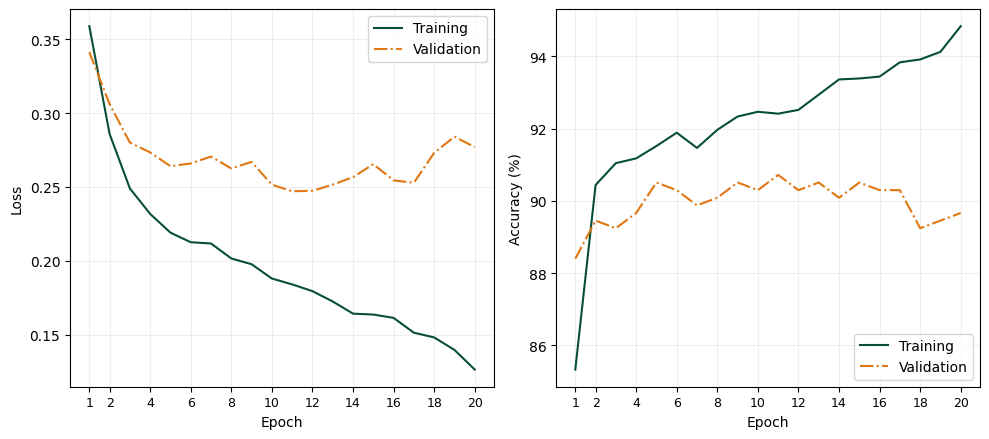

In [17]:
# Generate diagnostic curves
learning_curves(
    np.array(pedestrian_training_results)[:,0],    # training loss
    np.array(pedestrian_validation_results)[:,0],  # validation loss
    np.array(pedestrian_training_results)[:,1],    # training accuracy
    np.array(pedestrian_validation_results)[:,1]   # validation accuracy
)

### 8.2 Quantitative Out-of-Distribution Test Benchmarking

Evaluates the fully converged model on the independent `test_loader` partition. This quantitative audit measures true generalization capabilities against an analytical statistical chance baseline derived from the dataset's prior class distribution, outputting a confusion matrix for precision evaluation.

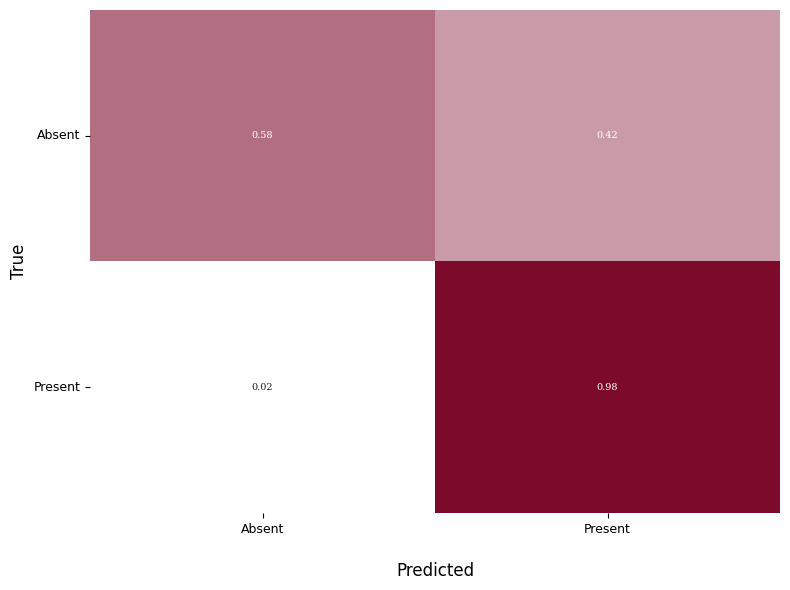


=== FINAL GENERALIZATION BENCHMARK ===
 -> Optimized Test Accuracy : 91.1765%
 -> Optimized Test Loss     : 0.2261
 -> Test Chance Baseline    : 83.4034%


In [18]:
test_loss, test_accuracy, chance_level = snn_pedestrian_test_evaluation_loop(
    test_loader=test_loader, 
    net=optimal_pedestrian_net, 
    criterion_cls=criterion_cls, 
    device=device,
    draw_matrix=True
)

print("\n=== FINAL GENERALIZATION BENCHMARK ===")
print(f" -> Optimized Test Accuracy : {np.round(test_accuracy, 4)}%")
print(f" -> Optimized Test Loss     : {np.round(test_loss, 4)}")
print(f" -> Test Chance Baseline    : {np.round(chance_level, 4)}%")

### 8.3 Qualitative Inference & Visual Mirroring

Implements a qualitative verification interface by pulling random samples from the unseen test partition. By mirroring the Ground Truth labels against the transient spatiotemporal categorical classifications (`PRESENT` vs `ABSENT`) generated by the network, this section validates operational reliability and visual alignment for edge deployment.

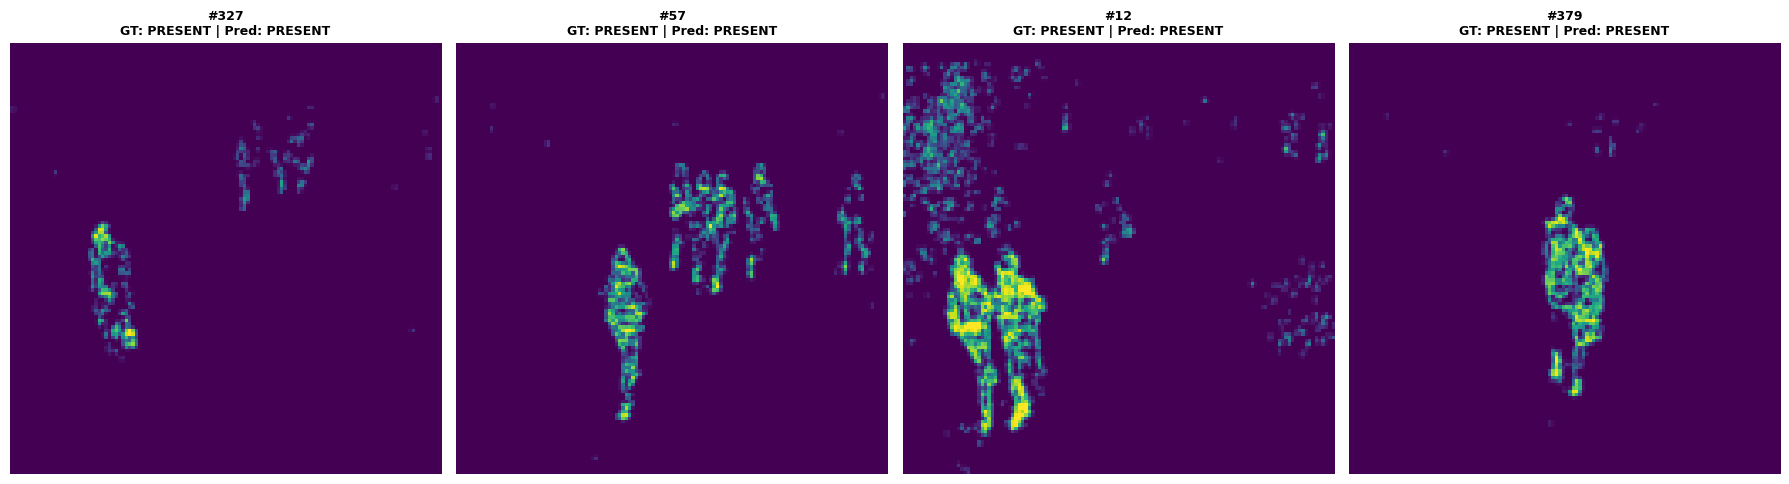

In [19]:
# Select four random samples from the test split for qualitative verification
test_indices = random.sample(range(len(test_dataset)), 4)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
optimal_pedestrian_net.eval()

with torch.no_grad():
    for ax, rnd_idx in zip(axes, test_indices):
        image_tensor, label_cls_gt = test_dataset[rnd_idx]
        image_tensor = image_tensor.to(device)

        pred_cls_raw = optimal_pedestrian_net(image_tensor.unsqueeze(0))
        pred_cls = 1.0 if pred_cls_raw.cpu().item() >= 0.0 else 0.0

        image_numpy = image_tensor.cpu().permute(1, 2, 0).numpy()
        ax.imshow(np.clip(image_numpy, 0, 1))

        gt_status = 'PRESENT' if label_cls_gt.item() == 1.0 else 'ABSENT'
        pred_status = 'PRESENT' if pred_cls == 1.0 else 'ABSENT'
        ax.set_title(f'#{rnd_idx}\nGT: {gt_status} | Pred: {pred_status}', fontsize=9, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()